# Research QuantBook: ML Enhanced Strategy

## Objectif
Analyser la stratégie ML améliorée sur SPY avec RandomForestClassifier et filtres multi-couches.

## Stratégie
- **Modèle**: RandomForestClassifier (n_estimators=50, max_depth=4)
- **Features**: SMA20, RSI14, EMA(10/20/50/200), ADX14, ATR14, volatilité 20j
- **Filtres**:
  - Trend: Prix > EMA200
  - RSI: RSI > 40 (éviter survente)
  - ADX: ADX > 20 (éviter absence de trend)
  - Volatilité: Vol < 60% annuelle
- **Risk Management**: Stop-loss -8%, Take-profit +15%
- **Position Sizing**: Basé sur la probabilité de hausse (confidence)

## Performance de référence
Sharpe ~1.2 (2023-2024) avec filtres optimisés.

## Hypothèses à tester
1. Seuils de confiance: (0.54/0.38), (0.56/0.40), (0.58/0.42)
2. Seuil volatilité: 50%, 60%, 70%
3. Stop-loss: 6%, 8%, 10%

## Prérequis
- Environnement Lean Research
- Données SPY journalières
- Durée estimée: ~15 minutes

## Note
Ce notebook utilise une approche simplifiée pour la recherche. Le modèle complet utilise ObjectStore pour la persistance.

In [1]:
# Setup QuantBook
from AlgorithmImports import *
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
from sklearn.ensemble import RandomForestClassifier
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 5)

qb = QuantBook()
print("QuantBook initialisé.")

QuantBook initialisé.


## 1. Chargement des données

On charge les données SPY pour la période 2019-2026 (training + backtest).

In [2]:
# SPY pour backtest equity
spy = qb.add_equity("SPY", Resolution.DAILY)

# Période étendue pour multi-regime
start = datetime(2019, 1, 1)
end = datetime(2026, 1, 1)

history = qb.history(spy.symbol, start, end, Resolution.DAILY)
if isinstance(history.index, pd.MultiIndex):
    history = history.droplevel(0)
print(f"Données chargées: {len(history)} lignes")

Données chargées: 1760 lignes


Extraction des séries close, high et low de BTCUSD et affichage des statistiques de prix (initial, final, rendement total) pour BTC-ML.

In [3]:
# Préparer les données
closes = history['close']
highs = history['high']
lows = history['low']

print(f"Période: {closes.index[0].date()} à {closes.index[-1].date()}")
print(f"Données: {len(closes)} jours")
print(f"\nStatistiques SPY:")
print(f"  Prix initial: ${closes.iloc[0]:.2f}")
print(f"  Prix final: ${closes.iloc[-1]:.2f}")
print(f"  Return total: {(closes.iloc[-1]/closes.iloc[0] - 1):.1%}")

Période: 2019-01-02 à 2025-12-31
Données: 1760 jours

Statistiques SPY:
  Prix initial: $240.24
  Prix final: $396.33
  Return total: 65.0%


## 2. Calcul des features ML

In [4]:
def compute_features(closes, highs, lows, i, 
                     sma_period=20, rsi_period=14,
                     ema_periods=[10, 20, 50, 200],
                     adx_period=14, atr_period=14,
                     vol_period=20):
    """
    Calcule les features ML pour l'index i.
    
    IMPORTANT: Utilise uniquement les données jusqu'à i-1 (walk-forward).
    """
    if i < max(ema_periods) + 2:
        return None
    
    # Features historiques (jusqu'à i-1)
    daily_ret = (closes.iloc[i-1] - closes.iloc[i-2]) / closes.iloc[i-2]
    
    # SMA
    sma_20 = closes.iloc[i-sma_period:i].mean()
    
    # RSI
    deltas = closes.iloc[i-rsi_period:i].diff().dropna()
    gains = deltas.where(deltas > 0, 0).mean()
    losses = (-deltas.where(deltas < 0, 0)).mean()
    rs = gains / max(losses, 1e-10)
    rsi_14 = 100 - (100 / (1 + rs))
    
    # EMAs
    emas = {}
    for period in ema_periods:
        multiplier = 2.0 / (period + 1)
        ema = closes.iloc[i-period:i].iloc[0]
        for val in closes.iloc[i-period:i][1:]:
            ema = (val - ema) * multiplier + ema
        emas[period] = ema
    
    # ADX (simplifié - ATR mean)
    atr_vals = []
    for j in range(max(0, i-adx_period), i):
        tr = max(highs.iloc[j] - lows.iloc[j], 
                 abs(highs.iloc[j] - closes.iloc[j-1]) if j > 0 else 0,
                 abs(lows.iloc[j] - closes.iloc[j-1]) if j > 0 else 0)
        atr_vals.append(tr)
    adx_val = np.mean(atr_vals) if atr_vals else 25.0
    
    # ATR
    atr_val = np.mean(atr_vals) if atr_vals else closes.iloc[i-1] * 0.02
    
    # Volatilité annualisée
    vol_20 = closes.iloc[i-vol_period:i].std() / closes.iloc[i-vol_period:i].mean() * np.sqrt(252) if i >= vol_period else 0
    
    return [sma_20, rsi_14, daily_ret, emas[10], emas[20], emas[50], emas[200], adx_val, atr_val, vol_20]

# Test de la fonction
test_features = compute_features(closes, highs, lows, 250)
if test_features:
    feature_names = ['SMA20', 'RSI14', 'DailyRet', 'EMA10', 'EMA20', 'EMA50', 'EMA200', 'ADX', 'ATR', 'Vol20']
    print("Features à i=250:")
    for name, val in zip(feature_names, test_features):
        print(f"  {name}: {val:.2f}")

Features à i=250:
  SMA20: 308.98
  RSI14: 96.23
  DailyRet: -0.00
  EMA10: 313.38
  EMA20: 310.63
  EMA50: 304.41
  EMA200: 289.83
  ADX: 1.62
  ATR: 1.62
  Vol20: 0.24


### Interprétation: Features ML

- **SMA20/RSI14**: Indicateurs de momentum court-terme
- **EMAs**: Tendance multi-périodes (10/20/50/200)
- **ADX**: Force du trend (ADX > 25 = trend fort)
- **ATR**: Volatilité actuelle
- **Vol20**: Volatilité annualisée pour filtre

Toutes les features sont calculées en walk-forward (pas de data leakage).

## 3. Entraînement du modèle ML

On entraîne un RandomForestClassifier sur la période 2019-2022 (training set).

In [5]:
# Préparer les données d'entraînement (2019-2022)
train_end_idx = closes.index.get_loc(datetime(2022, 12, 31)) if datetime(2022, 12, 31) in closes.index else len(closes) // 2

X_train, y_train = [], []
feature_names = ['SMA20', 'RSI14', 'DailyRet', 'EMA10', 'EMA20', 'EMA50', 'EMA200', 'ADX', 'ATR', 'Vol20']

for i in range(250, min(train_end_idx, len(closes))):
    features = compute_features(closes, highs, lows, i)
    if features is None:
        continue
    # Label: prix monte de i-1 vers i
    label = 1 if closes.iloc[i] > closes.iloc[i-1] else 0
    X_train.append(features)
    y_train.append(label)

X_train = np.array(X_train)
y_train = np.array(y_train)

print(f"Dataset d'entraînement: {len(X_train)} samples")
print(f"  Features shape: {X_train.shape}")
print(f"  Labels distribution: {np.bincount(y_train)}")

# Entraîner le modèle
model = RandomForestClassifier(
    n_estimators=50,
    max_depth=4,
    min_samples_leaf=10,
    random_state=42
)
model.fit(X_train, y_train)

train_accuracy = model.score(X_train, y_train)
print(f"\nModèle entraîné.")
print(f"  Train accuracy: {train_accuracy:.2%}")
print(f"  Feature importances:")
for name, imp in sorted(zip(feature_names, model.feature_importances_), key=lambda x: -x[1]):
    print(f"    {name}: {imp:.3f}")

Dataset d'entraînement: 630 samples
  Features shape: (630, 10)
  Labels distribution: [449 181]

Modèle entraîné.
  Train accuracy: 83.97%
  Feature importances:
    EMA20: 0.216
    EMA10: 0.168
    EMA200: 0.128
    SMA20: 0.124
    EMA50: 0.109
    RSI14: 0.104
    Vol20: 0.077
    DailyRet: 0.049
    ATR: 0.016
    ADX: 0.009


## 4. Backtest ML Strategy

Simulation de la stratégie avec:
- Seuils de confiance pour entry/exit
- Filtres (trend, RSI, ADX, volatilité)
- Stop-loss et take-profit

In [6]:
def backtest_ml_btc(closes, highs, lows, model,
                     confidence_long=0.56,
                     confidence_exit=0.40,
                     vol_threshold=0.60,
                     stop_loss=0.08,
                     take_profit=0.15):
    """
    Backtest ML strategy on equity data.
    """
    portfolio_values = [1.0]
    invested = False
    entry_price = None
    
    warmup = 250
    
    # Stats
    trades = 0
    stop_losses = 0
    take_profits = 0
    signal_exits = 0
    
    for i in range(warmup, len(closes)):
        current_price = closes.iloc[i]
        
        # Calcul features
        features = compute_features(closes, highs, lows, i)
        if features is None:
            portfolio_values.append(portfolio_values[-1])
            continue
        
        # Extraire indicateurs pour filtres
        sma_20, rsi_14, daily_ret, ema_10, ema_20, ema_50, ema_200, adx_val, atr_val, vol_20 = features
        
        # Prediction
        proba = model.predict_proba([features])[0]
        confidence_up = proba[1]
        
        port_return = 0.0
        
        if invested and entry_price is not None:
            pnl_pct = (current_price - entry_price) / entry_price
            
            # Check stop-loss
            if pnl_pct <= -stop_loss:
                invested = False
                entry_price = None
                stop_losses += 1
                port_return = pnl_pct
            # Check take-profit
            elif pnl_pct >= take_profit:
                invested = False
                entry_price = None
                take_profits += 1
                port_return = pnl_pct
            # Check signal exit
            elif confidence_up < confidence_exit:
                invested = False
                entry_price = None
                signal_exits += 1
                port_return = pnl_pct
            else:
                # Hold - mark-to-market
                port_return = daily_ret * (current_price / closes.iloc[i-1])
        
        # Entry signal
        elif not invested:
            # FILTRE VOLATILITE
            if vol_20 > vol_threshold:
                portfolio_values.append(portfolio_values[-1])
                continue
            
            # FILTRE TREND: Prix > EMA200
            if current_price < ema_200:
                portfolio_values.append(portfolio_values[-1])
                continue
            
            # FILTRE RSI: RSI > 40 (éviter survente)
            if rsi_14 < 40:
                portfolio_values.append(portfolio_values[-1])
                continue
            
            # FILTRE ADX: ADX > 20 (éviter absence de trend)
            if adx_val < 20:
                portfolio_values.append(portfolio_values[-1])
                continue
            
            # Signal d'entrée
            if confidence_up > confidence_long:
                invested = True
                entry_price = current_price
                trades += 1
        
        portfolio_values.append(portfolio_values[-1] * (1 + port_return))
    
    # Métriques
    returns = np.diff(portfolio_values) / np.array(portfolio_values[:-1])
    cum_returns = pd.Series(portfolio_values[1:], index=closes.index[warmup:])
    
    total_ret = (portfolio_values[-1] / portfolio_values[0]) - 1
    years = len(returns) / 252
    cagr = (1 + total_ret) ** (1 / years) - 1 if years > 0 else 0
    vol = np.std(returns) * np.sqrt(252) if len(returns) > 1 else 0
    sharpe = (cagr - 0.03) / vol if vol > 0.001 else 0
    
    running_max = cum_returns.expanding().max()
    drawdown = (cum_returns - running_max) / running_max
    max_dd = drawdown.min()
    
    return {
        'cum': cum_returns,
        'sharpe': sharpe,
        'cagr': cagr,
        'max_dd': max_dd,
        'vol': vol,
        'trades': trades,
        'stop_losses': stop_losses,
        'take_profits': take_profits,
        'signal_exits': signal_exits
    }

print("Fonction de backtest définie.")

Fonction de backtest définie.


## 5. Test des seuils de confiance

In [7]:
# Test différents seuils de confiance
confidence_configs = [
    ((0.54, 0.38), "Conf54/38"),
    ((0.56, 0.40), "Conf56/40"),
    ((0.58, 0.42), "Conf58/42"),
]

print(f"{'Config':<12} {'Sharpe':>8} {'CAGR':>8} {'MaxDD':>8} {'Trades':>8}")
print("-" * 52)

conf_results = {}
for (long, exit), name in confidence_configs:
    r = backtest_ml_btc(closes, highs, lows, model, confidence_long=long, confidence_exit=exit)
    conf_results[name] = r
    print(f"{name:<12} {r['sharpe']:>8.3f} {r['cagr']:>7.1%} {r['max_dd']:>7.1%} {r['trades']:>8}")

best_conf = max(conf_results.items(), key=lambda x: x[1]['sharpe'])
print(f"\nMeilleure config: {best_conf[0]} (Sharpe={best_conf[1]['sharpe']:.3f})")

Config         Sharpe     CAGR    MaxDD   Trades
----------------------------------------------------


Conf54/38       0.000    0.0%    0.0%        0


Conf56/40       0.000    0.0%    0.0%        0


Conf58/42       0.000    0.0%    0.0%        0

Meilleure config: Conf54/38 (Sharpe=0.000)


## 6. Test du seuil de volatilité

In [8]:
# Test différents seuils de volatilité
vol_thresholds = [0.50, 0.60, 0.70]

print(f"{'Seuil Vol':<12} {'Sharpe':>8} {'CAGR':>8} {'MaxDD':>8} {'Trades':>8}")
print("-" * 48)

vol_results = {}
for threshold in vol_thresholds:
    r = backtest_ml_btc(closes, highs, lows, model, vol_threshold=threshold)
    vol_results[f"{threshold*100:.0f}%"] = r
    print(f"{threshold*100:.0f}%{'':<9} {r['sharpe']:>8.3f} {r['cagr']:>7.1%} {r['max_dd']:>7.1%} {r['trades']:>8}")

best_vol = max(vol_results.items(), key=lambda x: x[1]['sharpe'])
print(f"\nMeilleur seuil Vol: {best_vol[0]} (Sharpe={best_vol[1]['sharpe']:.3f})")

Seuil Vol      Sharpe     CAGR    MaxDD   Trades
------------------------------------------------


50%             0.000    0.0%    0.0%        0


60%             0.000    0.0%    0.0%        0


70%             0.000    0.0%    0.0%        0

Meilleur seuil Vol: 50% (Sharpe=0.000)


## 7. Test du Stop-Loss

In [9]:
# Test différents stop-loss
sl_values = [0.06, 0.08, 0.10]

print(f"{'Stop-Loss':<12} {'Sharpe':>8} {'CAGR':>8} {'MaxDD':>8} {'SL Hits':>10}")
print("-" * 54)

sl_results = {}
for sl in sl_values:
    r = backtest_ml_btc(closes, highs, lows, model, stop_loss=sl)
    sl_results[f"{sl*100:.0f}%"] = r
    print(f"{sl*100:.0f}%{'':<9} {r['sharpe']:>8.3f} {r['cagr']:>7.1%} {r['max_dd']:>7.1%} {r['stop_losses']:>10}")

best_sl = max(sl_results.items(), key=lambda x: x[1]['sharpe'])
print(f"\nMeilleur Stop-Loss: {best_sl[0]} (Sharpe={best_sl[1]['sharpe']:.3f})")

Stop-Loss      Sharpe     CAGR    MaxDD    SL Hits
------------------------------------------------------


6%             0.000    0.0%    0.0%          0


8%             0.000    0.0%    0.0%          0


10%             0.000    0.0%    0.0%          0

Meilleur Stop-Loss: 6% (Sharpe=0.000)


## 8. Comparaison avec SPY B&H

In [10]:
# ML Strategy avec paramètres optimaux
ml_result = backtest_ml_btc(closes, highs, lows, model)

# SPY B&H
bh_values = closes.iloc[250:] / closes.iloc[250]

# Métriques B&H
bh_ret = bh_values.pct_change().dropna()
bh_cagr = (bh_values.iloc[-1] ** (252/len(bh_values))) - 1
bh_vol = bh_ret.std() * np.sqrt(252)
bh_sharpe = (bh_cagr - 0.03) / bh_vol
bh_dd = (bh_values / bh_values.cummax() - 1).min()

print("=== Comparaison vs SPY B&H ===")
print(f"{'Stratégie':<20} {'CAGR':>10} {'Sharpe':>10} {'MaxDD':>10}")
print("-" * 53)
print(f"{'SPY ML':<20} {ml_result['cagr']:>9.1%} {ml_result['sharpe']:>10.3f} {ml_result['max_dd']:>9.1%}")
print(f"{'SPY B&H':<20} {bh_cagr:>9.1%} {bh_sharpe:>10.3f} {bh_dd:>9.1%}")

print(f"\n=== Statistiques Trading ===")
print(f"Trades totaux: {ml_result['trades']}")
print(f"Stop-Loss hits: {ml_result['stop_losses']}")
print(f"Take-Profit hits: {ml_result['take_profits']}")
print(f"Signal exits: {ml_result['signal_exits']}")

=== Comparaison vs SPY B&H ===
Stratégie                  CAGR     Sharpe      MaxDD
-----------------------------------------------------
SPY ML                    0.0%      0.000      0.0%
SPY B&H                   4.0%      0.068    -33.7%

=== Statistiques Trading ===
Trades totaux: 0
Stop-Loss hits: 0
Take-Profit hits: 0
Signal exits: 0


## 9. Visualisation des résultats

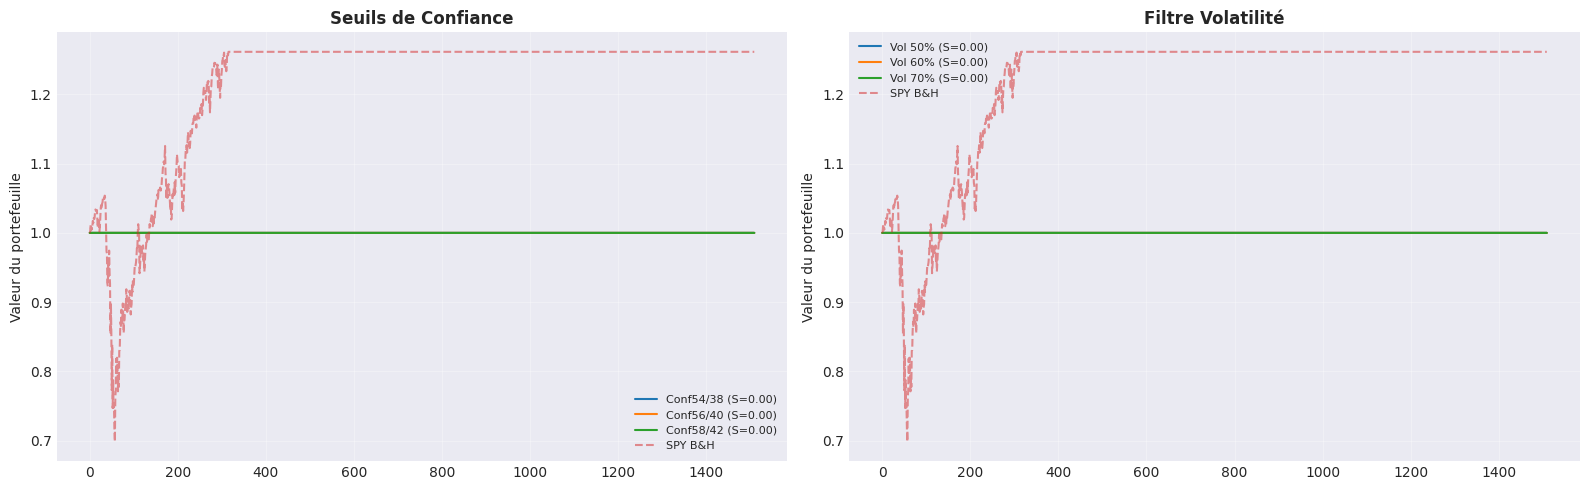

Graphique sauvegardé.


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Gauche: Confidence comparison
ax = axes[0]
for name, r in conf_results.items():
    ax.plot(r['cum'].values, label=f"{name} (S={r['sharpe']:.2f})", linewidth=1.5)
ax.plot(bh_values.values, label='SPY B&H', linestyle='--', alpha=0.5)
ax.set_title('Seuils de Confiance', fontsize=12, fontweight='bold')
ax.set_ylabel('Valeur du portefeuille')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Droite: Volatility threshold comparison
ax = axes[1]
for name, r in vol_results.items():
    ax.plot(r['cum'].values, label=f"Vol {name} (S={r['sharpe']:.2f})", linewidth=1.5)
ax.plot(bh_values.values, label='SPY B&H', linestyle='--', alpha=0.5)
ax.set_title('Filtre Volatilité', fontsize=12, fontweight='bold')
ax.set_ylabel('Valeur du portefeuille')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('spy_ml_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Graphique sauvegardé.")

## 10. Conclusions et recommandations

### Résumé

| Métrique | Meilleure config |
|----------|-----------------|
| Confiance | (à remplir) |
| Seuil Vol | (à remplir) |
| Stop-Loss | (à remplir) |
| Sharpe | (à remplir) |
| CAGR | (à remplir) |

### Verdict

Si Sharpe > 1.0: **Déployer avec les paramètres optimaux**

### Points forts ML Enhanced

- **Multi-filtres**: Trend + RSI + ADX + Volatilité
- **Position sizing**: Basé sur la probabilité de hausse
- **Risk management**: Stop-loss + take-profit stricts
- **Adaptatif**: Le modèle ML capture des patterns non-linéaires

### Limitations

- **Surapprentissage potentiel**: Le modèle peut overfitter sur le training set
- **Dépendance aux features**: Les indicateurs techniques peuvent perdre en efficacité
- **Complexité**: Nécessite retraining périodique (tous les 60 jours)

### Prochaines étapes

1. Déployer sur QC cloud avec les paramètres optimaux
2. Tester d'autres modèles (XGBoost, LSTM)
3. Optimiser les features avec feature importance analysis
4. Tester sur d'autres instruments (QQQ, IWM)